 MODEL: K-NEAREST NEIGHBORS (KNN)

1. INSTALL LIBRARIES


In [1]:
!pip install pandas scikit-learn matplotlib seaborn

2. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

 3. MOUNT GOOGLE DRIVE


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


4. LOAD DATASET FROM DRIVE

In [4]:
data_path = "/content/drive/MyDrive/ML_Dataset/mobile_price_predicition dataset.csv"
data = pd.read_csv(data_path)

 5. DATA UNDERSTANDING


In [5]:
print("\n===== DATA INFORMATION =====")
print("Shape:", data.shape)
print("\nColumns:\n", data.columns)

print("\n===== FIRST 5 ROWS =====")
print(data.head())

print("\n===== LAST 5 ROWS =====")
print(data.tail())


===== DATA INFORMATION =====
Shape: (2000, 21)

Columns:
 Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

===== FIRST 5 ROWS =====
   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7      

6. DATA TYPES & MISSING VALUES


In [6]:
print("\n===== DATA TYPES =====")
print(data.dtypes)

print("\n===== MISSING VALUES =====")
print(data.isnull().sum())


===== DATA TYPES =====
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object

===== MISSING VALUES =====
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int

 7. STATISTICAL SUMMARY


In [7]:
print("\n===== STATISTICAL SUMMARY =====")
print(data.describe())


===== STATISTICAL SUMMARY =====
       battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
min       501.000000     0.0000     0.500000     0.000000     0.000000   
25%       851.750000     0.0000     0.700000     0.000000     1.000000   
50%      1226.000000     0.0000     1.500000     1.000000     3.000000   
75%      1615.250000     1.0000     2.200000     1.000000     7.000000   
max      1998.000000     1.0000     3.000000     1.000000    19.000000   

            four_g   int_memory        m_dep    mobile_wt      n_cores  ...  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  ...   
mean      0.521500    32.046500     0.501750   140.249000     4.520500  ...   
std       0.499662    18.145715     0.288416    35.399655     2

 8. DATA VISUALIZATION

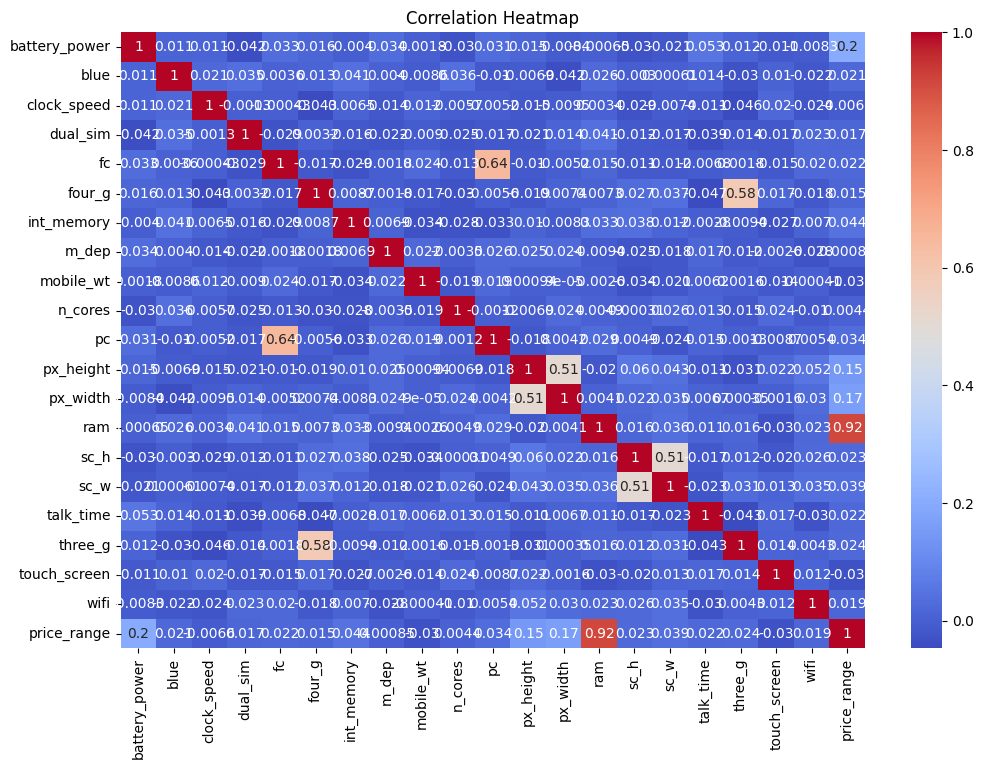

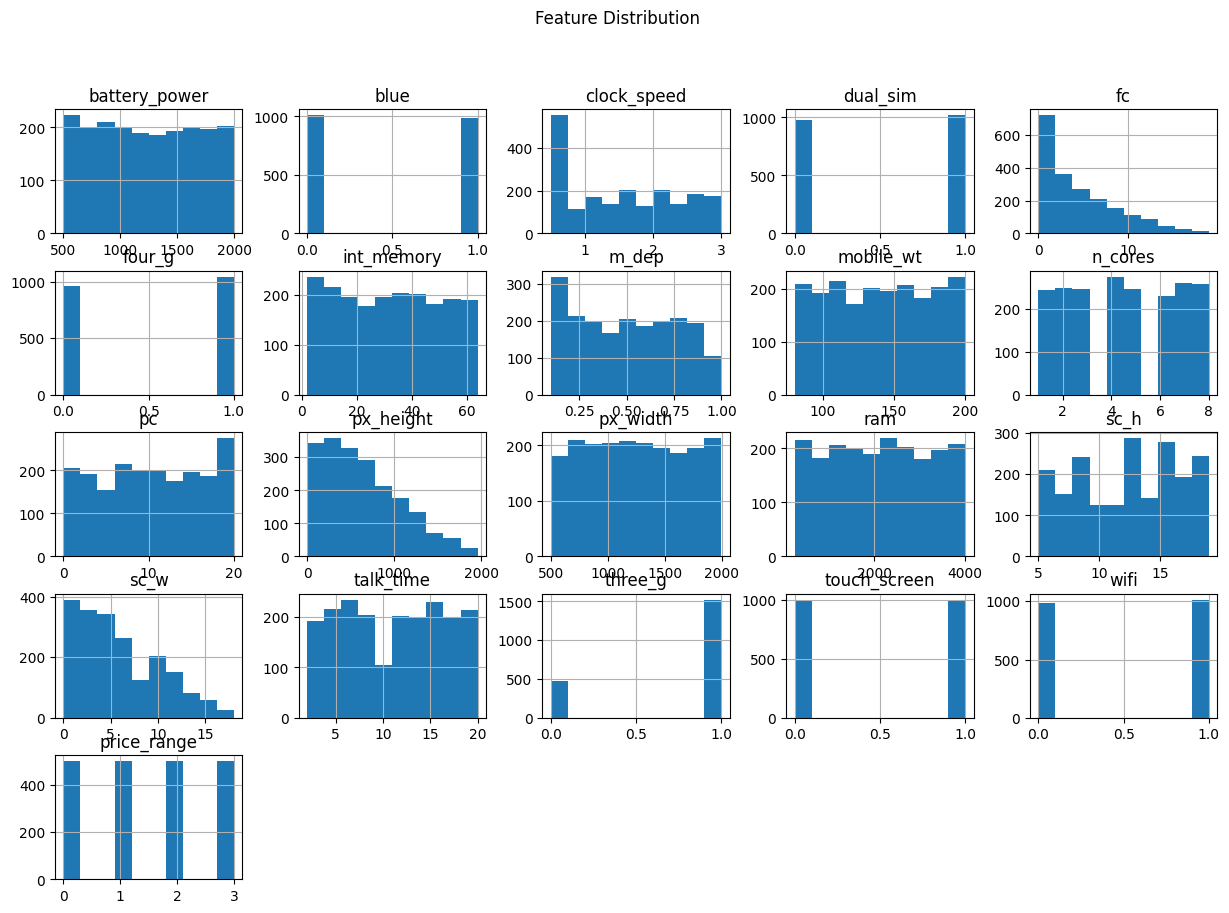

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

data.hist(figsize=(15,10))
plt.suptitle("Feature Distribution")
plt.show()

9. FEATURE & TARGET

In [10]:
X = data.drop("price_range", axis=1)
y = data["price_range"]

10. FEATURE SCALING (IMPORTANT FOR KNN)

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

11. 80:20 SPLIT

In [12]:
print("\n===== KNN MODEL (80:20) =====")

X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


===== KNN MODEL (80:20) =====


 12. MODEL TRAINING (80:20)

In [13]:
model_80 = KNeighborsClassifier(n_neighbors=5)
model_80.fit(X_train_80, y_train_80)


KNeighborsClassifier()

13. PREDICTION (80:20)




In [14]:
y_pred_80 = model_80.predict(X_test_80)

 14. ACCURACY (80:20)

In [15]:
train_acc_80 = model_80.score(X_train_80, y_train_80)
test_acc_80 = accuracy_score(y_test_80, y_pred_80)

print("Training Accuracy:", train_acc_80)
print("Testing Accuracy:", test_acc_80)

Training Accuracy: 0.696875
Testing Accuracy: 0.53


 15. CLASSIFICATION REPORT (80:20)

In [16]:
print("\nClassification Report (80:20):\n")
print(classification_report(y_test_80, y_pred_80))



Classification Report (80:20):

              precision    recall  f1-score   support

           0       0.70      0.72      0.71       105
           1       0.35      0.45      0.39        91
           2       0.36      0.38      0.37        92
           3       0.80      0.54      0.64       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400



 16. CONFUSION MATRIX (80:20)

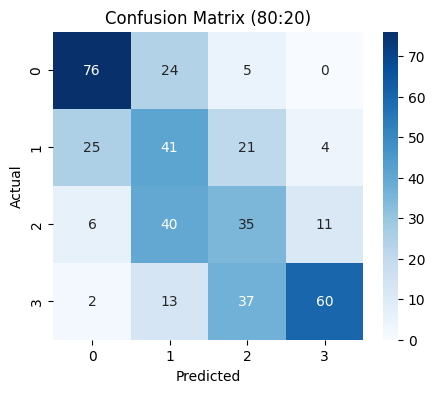

In [17]:
m_80 = confusion_matrix(y_test_80, y_pred_80)

plt.figure(figsize=(5,4))
sns.heatmap(m_80, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix (80:20)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

17. 70:30 SPLIT

In [18]:
print("\n===== KNN MODEL (70:30) =====")

X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)



===== KNN MODEL (70:30) =====


18. MODEL TRAINING (70:30)

In [19]:
model_70 = KNeighborsClassifier(n_neighbors=5)
model_70.fit(X_train_70, y_train_70)

KNeighborsClassifier()

19. PREDICTION (70:30)

In [20]:
y_pred_70 = model_70.predict(X_test_70)

20. ACCURACY (70:30)

In [21]:
train_acc_70 = model_70.score(X_train_70, y_train_70)
test_acc_70 = accuracy_score(y_test_70, y_pred_70)

print("Training Accuracy:", train_acc_70)
print("Testing Accuracy:", test_acc_70)

Training Accuracy: 0.7114285714285714
Testing Accuracy: 0.5183333333333333


21. CLASSIFICATION REPORT (70:30)

In [22]:
print("\nClassification Report (70:30):\n")
print(classification_report(y_test_70, y_pred_70))


Classification Report (70:30):

              precision    recall  f1-score   support

           0       0.66      0.73      0.69       151
           1       0.39      0.47      0.42       146
           2       0.38      0.42      0.40       148
           3       0.74      0.46      0.57       155

    accuracy                           0.52       600
   macro avg       0.54      0.52      0.52       600
weighted avg       0.55      0.52      0.52       600



22. CONFUSION MATRIX (70:30)

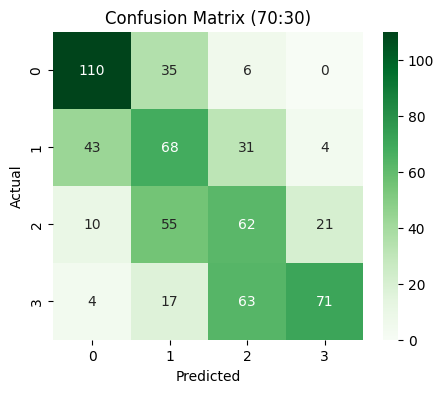

In [23]:
cm_70 = confusion_matrix(y_test_70, y_pred_70)

plt.figure(figsize=(5,4))
sns.heatmap(cm_70, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix (70:30)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


23. COMPARISON TABLE

In [24]:
print("\n===== FINAL COMPARISON TABLE =====")

results = pd.DataFrame({
    "Split": ["80:20", "70:30"],
    "Training Accuracy": [train_acc_80, train_acc_70],
    "Testing Accuracy": [test_acc_80, test_acc_70]
})

print(results)


===== FINAL COMPARISON TABLE =====
   Split  Training Accuracy  Testing Accuracy
0  80:20           0.696875          0.530000
1  70:30           0.711429          0.518333


 24. K VALUE ANALYSIS


===== K VALUE ANALYSIS =====


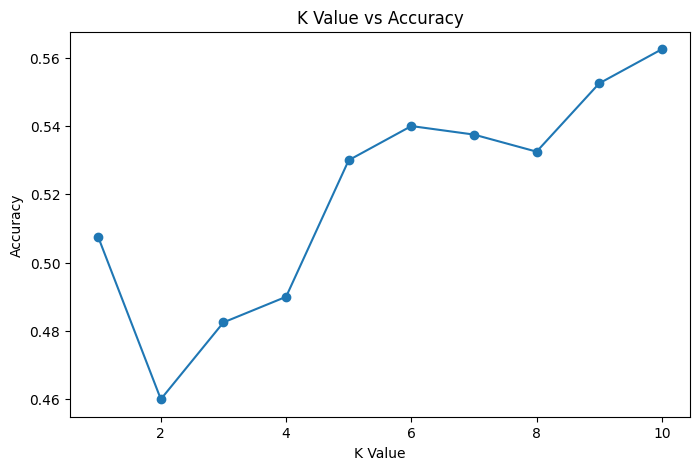

In [25]:
print("\n===== K VALUE ANALYSIS =====")

k_values = list(range(1, 11))
accuracy_list = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_80, y_train_80)
    pred_temp = knn_temp.predict(X_test_80)
    acc = accuracy_score(y_test_80, pred_temp)
    accuracy_list.append(acc)

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_list, marker='o')
plt.title("K Value vs Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.show()


25. SAMPLE PREDICTION

In [26]:
sample = X_scaled[0].reshape(1, -1)
prediction = model_80.predict(sample)

print("\nSample Prediction:", prediction)


Sample Prediction: [1]
